# BBC News (news articles)


In [83]:
from pathlib import Path
import pandas as pd

NEWS_DIR = Path("../data/raw/news/bbc")

data = []

for category_dir in NEWS_DIR.iterdir():
    if category_dir.is_dir():
        label = category_dir.name
        
        for file in category_dir.glob("*.txt"):
            text = file.read_text(encoding="latin-1")  # BBC uses latin-1 sometimes
            data.append({
                "label": label,
                "text": text,
                "filename": file.name
            })

news = pd.DataFrame(data)

news.shape

(2225, 3)

In [84]:
news.head()

,label,text,filename
0,entertainment,Musicians to tackle US red tape\n\nMusicians' ...,289.txt
1,entertainment,"U2's desire to be number one\n\nU2, who have w...",262.txt
2,entertainment,Rocker Doherty in on-stage fight\n\nRock singe...,276.txt
3,entertainment,Snicket tops US box office chart\n\nThe film a...,060.txt
4,entertainment,Ocean's Twelve raids box office\n\nOcean's Twe...,074.txt


In [85]:
news["label"].value_counts()

label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [86]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     2225 non-null   object
 1   text      2225 non-null   object
 2   filename  2225 non-null   object
dtypes: object(3)
memory usage: 52.3+ KB


In [87]:
news.isna().sum()

label       0
text        0
filename    0
dtype: int64

In [88]:
s = news["text"].fillna("").astype(str).str.strip()

{
    "total": len(s),
    "empty": (s == "").sum(),
    "empty_pct": (s == "").mean() * 100,
    "under_20_words": (s.str.split().str.len() < 20).sum(),
}

{'total': 2225,
 'empty': np.int64(0),
 'empty_pct': np.float64(0.0),
 'under_20_words': np.int64(0)}

In [89]:
duplicates = s.duplicated().sum()
duplicates, duplicates / len(s) * 100

(np.int64(98), np.float64(4.404494382022472))

In [90]:
stats = pd.DataFrame({
    "num_chars": s.str.len(),
    "num_words": s.str.split().str.len(),
})

In [91]:
stats.describe().T

,count,mean,std,min,25%,50%,75%,max
num_chars,2225.0,2264.788764,1364.307123,502.0,1447.0,1966.0,2803.0,25484.0
num_words,2225.0,384.040449,238.174497,89.0,246.0,332.0,471.0,4432.0


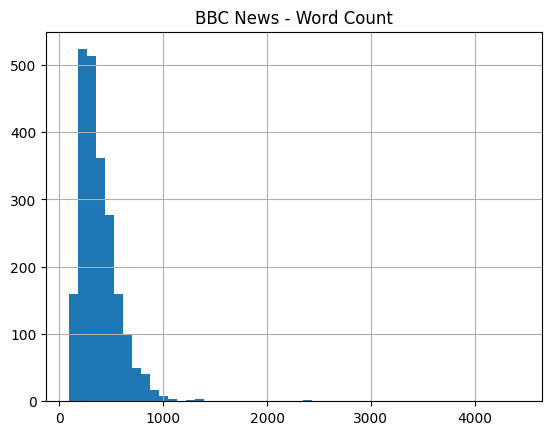

In [92]:
import matplotlib.pyplot as plt

stats["num_words"].hist(bins=50)
plt.title("BBC News - Word Count")
plt.show()

In [93]:
news["num_words"] = s.str.split().str.len()

news.groupby("label")["num_words"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
business,510.0,328.880392,135.919077,140.0,233.0,297.0,388.75,891.0
entertainment,386.0,330.621762,261.795254,143.0,225.0,262.5,360.00,3482.0
politics,417.0,453.973621,300.120275,89.0,317.0,439.0,529.00,4432.0
sport,511.0,329.262231,187.963267,114.0,204.0,288.0,409.50,1662.0
tech,401.0,502.695761,239.849176,162.0,338.0,447.0,629.00,2969.0


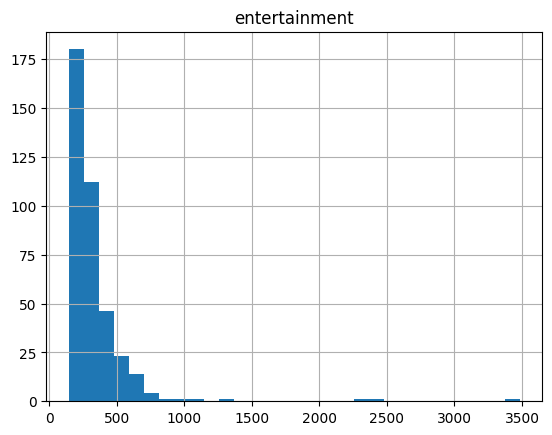

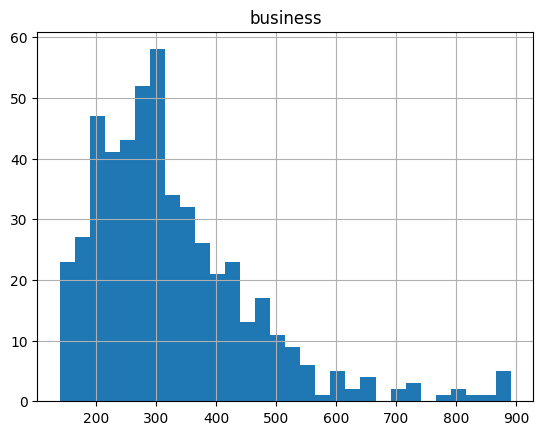

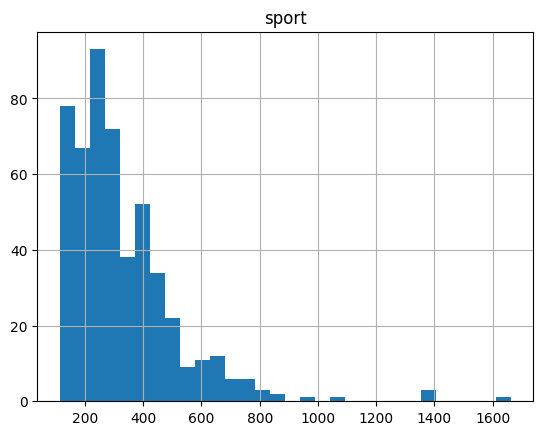

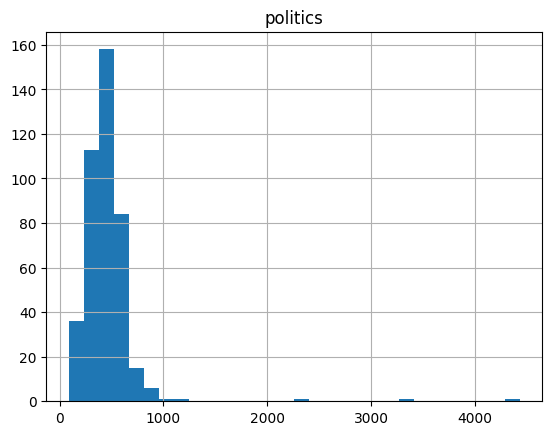

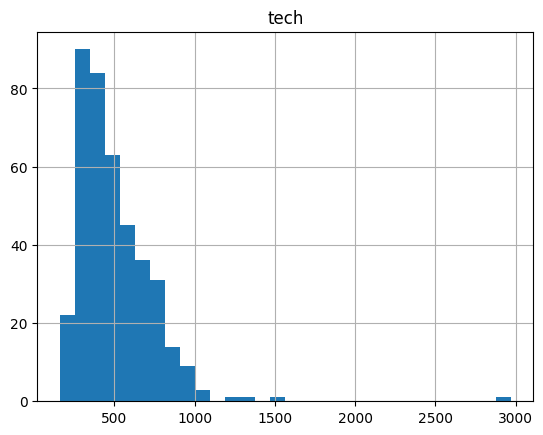

In [94]:
for label in news["label"].unique():
    news[news["label"] == label]["num_words"].hist(bins=30)
    plt.title(label)
    plt.show()

In [95]:
structure = pd.DataFrame({
    "has_numbers": s.str.contains(r"\d", regex=True),
    "has_dates": s.str.contains(r"\b\d{4}\b", regex=True),
    "has_url": s.str.contains(r"http|www", regex=True),
})

In [96]:
structure.mean() * 100

has_numbers    95.101124
has_dates      57.797753
has_url         0.134831
dtype: float64

In [97]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def top_words(label):
    subset = news[news["label"] == label]["text"]
    
    vec = CountVectorizer(stop_words="english", max_features=5000)
    X = vec.fit_transform(subset)
    
    freqs = np.asarray(X.sum(axis=0)).ravel()
    words = np.array(vec.get_feature_names_out())
    
    top_idx = freqs.argsort()[::-1][:15]
    
    return pd.DataFrame({
        "word": words[top_idx],
        "freq": freqs[top_idx]
    })

In [98]:
top_words("business")

,word,freq
0,said,1680
1,year,713
2,mr,600
3,market,434
4,new,417
5,company,416
6,growth,385
7,firm,362
8,economy,359
9,government,341


In [99]:
top_words("sport")

,word,freq
0,said,942
1,year,494
2,game,482
3,england,461
4,time,423
5,win,419
6,world,388
7,players,308
8,team,302
9,play,296


INSIGHTS:
- dataset quality is very clean: no missing values, no mepty documents nad no very short texts (no much cleaning needed)
- class distribtuion is very balanced so no need to resample or class weight
- 98 duplicate articles, have to remove them based oon text
- length distribtuion: right skewed + outliers (might need to truncate text by first 500-800 words)
- category differences in length (might be good to normalize)
- structural signals: contain numbers/dates frequently and almost no urls (might contrast with emails). IMPORTANT FOR CLASSIFICATION
- Vocabulary → VERY strong topic signals topic-driven classification


your classifier might rely on:
keywords (football, market, government)
instead of: document structure
That weakens your assignment justification (document classification)


# Enron (emails)


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

In [101]:
emails = pd.read_csv("../data/raw/emails/enron_spam_data.csv")
emails.shape

(33716, 5)

In [102]:
emails.head()

,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


In [103]:
emails.columns.tolist()

['Unnamed: 0', 'Subject', 'Message', 'Spam/Ham', 'Date']

In [104]:
emails.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  33716 non-null  int64 
 1   Subject     33716 non-null  object
 2   Message     33664 non-null  object
 3   Spam/Ham    33716 non-null  object
 4   Date        33716 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.3+ MB


In [105]:
emails.isna().sum().sort_values(ascending=False)

Message       52
Unnamed: 0     0
Subject        0
Spam/Ham       0
Date           0
dtype: int64

In [106]:
emails["text"] = (
    emails["Subject"].fillna("").astype(str) + " " +
    emails["Message"].fillna("").astype(str)
).str.strip()

emails[["Subject", "Message", "text"]].head()

,Subject,Message,text
0,christmas tree farm pictures,NaN,christmas tree farm pictures
1,"vastar resources , inc .","gary , production from the high island larger ...","vastar resources , inc . gary , production fro..."
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,calpine daily gas nomination - calpine daily g...
3,re : issue,fyi - see note below - already done .\nstella\...,re : issue fyi - see note below - already done...
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,meter 7268 nov allocation fyi .\n- - - - - - -...


In [107]:
s = emails["text"].fillna("").astype(str).str.strip()

{
    "total": len(s),
    "empty": int((s == "").sum()),
    "empty_pct": round((s == "").mean() * 100, 2),
    "under_5_words": int((s.str.split().str.len() < 5).sum()),
    "under_20_words": int((s.str.split().str.len() < 20).sum()),
}

{'total': 33716,
 'empty': 0,
 'empty_pct': np.float64(0.0),
 'under_5_words': 16,
 'under_20_words': 498}

In [108]:
duplicates = s.duplicated().sum()
{
    "duplicate_text_rows": int(duplicates),
    "duplicate_pct": round(duplicates / len(s) * 100, 2)
}

{'duplicate_text_rows': 17806, 'duplicate_pct': np.float64(52.81)}

In [109]:
emails[s.duplicated(keep=False)][["Subject", "Message"]].head(10)

,Subject,Message
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc
148,global risk management operations,"recognizing enron  , s increasing worldwide p..."
197,the 1999 form w - 2 and retiree tax form 1099 - r,the 1999 form w - 2 and retiree tax form 1099 ...
228,road - show . com q 4 i . com choose enron to ...,"houston  ) enron broadband services ( ebs ) ,..."
229,enron and chase manhattan bank sign long - ter...,agreement\nhouston and new york  ) enron ener...
230,organization announcement,enron purchases billions of dollars of product...
258,energy operations promotions,i am pleased to announce the following promoti...
268,fortune most admired ranking,congratulations ! for an unprecedented five ye...
505,calpine daily gas nomination,- calpine daily gas nomination 1 . doc
604,new financial operations contacts for energy o...,i just wanted to give all of you an update to ...


In [110]:
stats = pd.DataFrame({
    "num_chars": s.str.len(),
    "num_words": s.str.split().str.len(),
    "num_lines": s.str.count(r"\n") + 1,
})
stats.describe().T

,count,mean,std,min,25%,50%,75%,max
num_chars,33716.0,1659.376854,4206.398398,3.0,680.0,887.0,1714.0,228368.0
num_words,33716.0,364.762309,838.077937,1.0,165.0,190.0,365.0,45450.0
num_lines,33716.0,26.154645,40.988258,1.0,7.0,16.0,28.0,1768.0


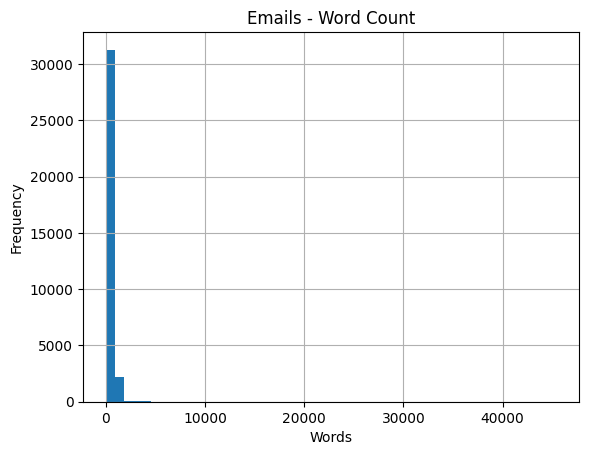

In [111]:
stats["num_words"].hist(bins=50)
plt.title("Emails - Word Count")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [112]:
emails.loc[stats["num_words"].sort_values().index[:10], ["Subject", "Message"]]

,Subject,Message
1655,revised,NaN
29109,website,NaN
7569,fyi,NaN
2537,house pictures,NaN
3273,gymnastics pictures,NaN
7136,elena chilkina,hi
13257,password - fast,NaN
13760,please see attached,NaN
6974,this,hurricane elana\n
0,christmas tree farm pictures,NaN


In [113]:
emails.loc[stats["num_words"].sort_values(ascending=False).index[:10], ["Subject", "Message"]]

,Subject,Message
14254,enron mentions,enron : a wake - up call\nthe wall street jour...
13901,enron mentions - 11 / 09 / 01 - 11 / 10 / 01,"rival to buy enron , top energy trader , after..."
14190,enron mentions,fall of a power giant : bailout is unlikely if...
14123,enron mentions - 11 / 24 / 01 - 11 / 25 / 01,accounting peer review gets more scrutiny\nthe...
14146,enron mentions,enron and dynegy discuss plan to cut price of ...
14167,enron mentions,don ' t bet it all on your employer ; the plun...
13602,enron mentions,enron discusses credit line of $ 1 billion to ...
13610,enron mentions,enron discusses credit line of $ 1 billion to ...
13588,enron mentions,enron discusses credit line of $ 1 billion to ...
13867,enron mentions,enron slashes profits since 1997 by 20 % - - -...


In [114]:
emails["num_words"] = s.str.split().str.len()
emails["num_words"].describe()

count    33716.000000
mean       364.762309
std        838.077937
min          1.000000
25%        165.000000
50%        190.000000
75%        365.000000
max      45450.000000
Name: num_words, dtype: float64

In [115]:
if "Spam/Ham" in emails.columns:
    emails["Spam/Ham"].value_counts(dropna=False)

In [116]:
if "Spam/Ham" in emails.columns:
    emails.groupby("Spam/Ham")["num_words"].describe()

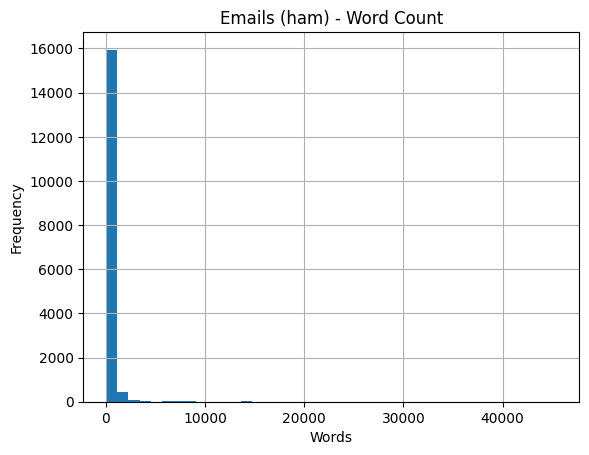

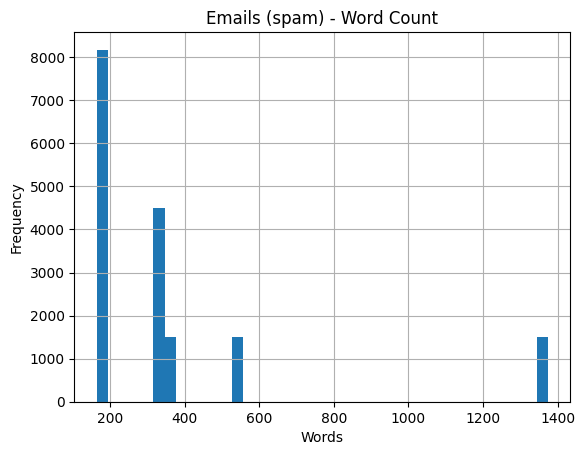

In [117]:
if "Spam/Ham" in emails.columns:
    for label in emails["Spam/Ham"].dropna().unique():
        emails.loc[emails["Spam/Ham"] == label, "num_words"].hist(bins=40)
        plt.title(f"Emails ({label}) - Word Count")
        plt.xlabel("Words")
        plt.ylabel("Frequency")
        plt.show()

In [118]:
structure = pd.DataFrame({
    "has_email": s.str.contains(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", regex=True, na=False),
    "has_url": s.str.contains(r"http[s]?://|www\.", regex=True, na=False),
    "has_phone": s.str.contains(r"\+?\d[\d\-\s]{7,}\d", regex=True, na=False),
    "has_numbers": s.str.contains(r"\d", regex=True, na=False),
    "has_currency": s.str.contains(r"[$€£]", regex=True, na=False),
    "has_subject_word": s.str.contains(r"\bsubject\b", case=False, regex=True, na=False),
    "has_from_word": s.str.contains(r"\bfrom\b", case=False, regex=True, na=False),
    "has_to_word": s.str.contains(r"\bto\b", case=False, regex=True, na=False),
    "has_cc_word": s.str.contains(r"\bcc\b", case=False, regex=True, na=False),
    "has_forward": s.str.contains(r"\bfw:|\bfwd:", case=False, regex=True, na=False),
    "has_reply": s.str.contains(r"\bre:", case=False, regex=True, na=False),
    "has_attachment_word": s.str.contains(r"\battachment\b|\battached\b", case=False, regex=True, na=False),
})
(structure.mean() * 100).sort_values(ascending=False)

has_numbers            94.180804
has_to_word            77.396488
has_from_word          61.321035
has_subject_word       46.064183
has_cc_word            38.002729
has_phone              37.166331
has_attachment_word    29.647645
has_currency           20.245581
has_email               0.000000
has_url                 0.000000
has_forward             0.000000
has_reply               0.000000
dtype: float64

In [119]:
if "Spam/Ham" in emails.columns:
    structure_by_label = pd.concat(
        [emails["Spam/Ham"], structure.astype(int)],
        axis=1
    ).groupby("Spam/Ham").mean() * 100
    
    structure_by_label.T

In [120]:
noise = pd.DataFrame({
    "digit_ratio": s.apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1)),
    "uppercase_ratio": s.apply(lambda x: sum(c.isupper() for c in x) / max(len(x), 1)),
    "newline_ratio": s.apply(lambda x: x.count("\n") / max(len(x), 1)),
    "punct_ratio": s.apply(lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace()) / max(len(x), 1)),
})
noise.describe().T

,count,mean,std,min,25%,50%,75%,max
digit_ratio,33716.0,0.035871,0.035416,0.0,0.013529,0.028331,0.048529,0.589968
uppercase_ratio,33716.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
newline_ratio,33716.0,0.016200,0.007405,0.0,0.011739,0.017503,0.021390,0.111111
punct_ratio,33716.0,0.065778,0.039152,0.0,0.032877,0.054783,0.105882,0.402131


In [121]:
emails.loc[noise["newline_ratio"].sort_values(ascending=False).index[:10], ["Subject", "Message"]]

,Subject,Message
734,wellhead,encina has some tru ups .\nmeter\nvance new ma...
12112,re : re :,reply : yes\norig :\n> fr : louise . kitchen @...
9440,re : grades,thank you ! - pvc\nat 09 : 19 am 5 / 3 / 01 - ...
9484,re : grades,thank you ! - pam\nat 08 : 15 am 5 / 4 / 01 - ...
6182,itinerary,"phelim ,\nfyi\nvince"
11437,direct reports,louise ' s :\nkevin presto\ndave duran\ntim be...
7106,re :,cheers vince\nsee you there .\nsimon\n- - - - ...
9472,grades,"pam ,\nanother term paper :\njohn ganguzza\nne..."
9444,re : grades,got them - thank you ! - pvc\nat 05 : 21 pm 5 ...
29110,transwestern scheduled volumes,february 2002 scheduled\nfriday 08\nwest ( 103...


In [122]:
emails.loc[noise["uppercase_ratio"].sort_values(ascending=False).index[:10], ["Subject", "Message"]]

,Subject,Message
0,christmas tree farm pictures,NaN
22488,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...
22486,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...
22485,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...
22484,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...
22483,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...
22482,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...
22481,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...
22480,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...
22479,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...


In [123]:
vec = CountVectorizer(stop_words="english", max_features=5000)
X = vec.fit_transform(s)

freqs = np.asarray(X.sum(axis=0)).ravel()
words = np.array(vec.get_feature_names_out())

top_idx = freqs.argsort()[::-1][:20]

pd.DataFrame({
    "word": words[top_idx],
    "freq": freqs[top_idx]
})

,word,freq
0,enron,105886
1,ubs,42567
2,subject,39089
3,message,36027
4,ect,35331
5,com,33567
6,ivanhoe,31516
7,07,29344
8,mail,28077
9,2002,27018


In [124]:
if "Spam/Ham" in emails.columns:
    def top_words_for_label(df, label_value, top_n=20):
        subset = df.loc[df["Spam/Ham"] == label_value, "text"].fillna("").astype(str)
        vec = CountVectorizer(stop_words="english", max_features=5000)
        X = vec.fit_transform(subset)
        freqs = np.asarray(X.sum(axis=0)).ravel()
        words = np.array(vec.get_feature_names_out())
        top_idx = freqs.argsort()[::-1][:top_n]
        return pd.DataFrame({"word": words[top_idx], "freq": freqs[top_idx]})

    top_words_for_label(emails, "ham")

In [125]:
if "Spam/Ham" in emails.columns:
    top_words_for_label(emails, "spam")

In [126]:
summary = pd.Series({
    "n_rows": len(emails),
    "n_unique_texts": s.nunique(),
    "duplicate_pct": round(s.duplicated().mean() * 100, 2),
    "avg_words": round(stats["num_words"].mean(), 2),
    "median_words": round(stats["num_words"].median(), 2),
    "avg_lines": round(stats["num_lines"].mean(), 2),
    "has_email_pct": round(structure["has_email"].mean() * 100, 2),
    "has_url_pct": round(structure["has_url"].mean() * 100, 2),
    "has_forward_pct": round(structure["has_forward"].mean() * 100, 2),
    "has_reply_pct": round(structure["has_reply"].mean() * 100, 2),
})
summary

n_rows             33716.00
n_unique_texts     15910.00
duplicate_pct         52.81
avg_words            364.76
median_words         190.00
avg_lines             26.15
has_email_pct          0.00
has_url_pct            0.00
has_forward_pct        0.00
has_reply_pct          0.00
dtype: float64

In [127]:
# optional: inspect a few random examples
emails[["Subject", "Message", "Spam/Ham"]].sample(5, random_state=42)

,Subject,Message,Spam/Ham
3820,re : tenaska iv,i tried calling you this am but your phone rol...,spam
3504,neon,- bammel neon groups - fall 2001 . doc,ham
30823,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",spam
22501,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...,spam
29593,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",spam


THIS DATAST IS LARGE, BUT VERY NOISY
- 33,716 emails
- only 52 missing Message
- no empty combined texts
- so availability is good
- Unnamed: 0 is just an index column (drop it later)

The biggest issue is duplicates
- 17,806 duplicate texts
- 52.81% duplicates (this is extremely high) REMOVE THEM

Email length are very skewed 
- remove extreme outliers or truncate texts

there are few very short emails
- some are valid emails like “fyi”, “please see attached”, but many are too weak to help the model
- would be good to remove VERY short emails

Structural signals are strong

suspicious
- has_email = 0
- has_url = 0
- has_forward = 0
- has_reply = 0
could mean that regex likely missed them because the dataset is heavily normalized with spaces
later: improve regext patterns for this dataset format

uppercase_ratio = 0 everywhere ALREADY LOWERCASED

Top words show header and corpus artifacts, which means that it might learn email fromatting and more (might consider to remove obvious emtadata aritfact, but keep genuine email structure words if they help document-type classification)

IGNORE SPAM/HAM

HISTOGRAMS show extreme skew (doesn't matter cuz we're not doing spam classification):
- ham seems much more variable and contains giant emails
- spam looks more concentrated


# CUAD (contracts)

looking at the structure that data collection gave, we will use the txt contracts for the classification and master_clauses.csv only to verify alignment and understand metadata

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [129]:
CONTRACTS_DIR = Path("../data/raw/contracts/CUAD_v1")
TXT_DIR = CONTRACTS_DIR / "full_contract_txt"
MASTER_CSV = CONTRACTS_DIR / "master_clauses.csv"

TXT_DIR.exists(), MASTER_CSV.exists()

(True, True)

In [130]:
data = []

for file in TXT_DIR.glob("*.txt"):
    try:
        text = file.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        text = file.read_text(encoding="latin-1")
    
    data.append({
        "filename": file.name,
        "contract_name": file.stem,
        "text": text
    })

contracts = pd.DataFrame(data)
contracts.shape

(510, 3)

In [131]:
contracts.head()

,filename,contract_name,text
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,EXHIBIT 10.6\n\n ...
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...","WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...",Exhibit 10.26 CONFIDENTIAL TREATMENT HAS BE...
2,LohaCompanyltd_20191209_F-1_EX-10.16_11917878_...,LohaCompanyltd_20191209_F-1_EX-10.16_11917878_...,Exhibit 10.16 SUPPLY CONTRACT Contract No: Dat...
3,CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WE...,CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WE...,1 ...
4,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEME...,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,Exhibit 1\n\nJOINT FILING AGREEMENT\n\nThe und...


In [132]:
contracts.columns.tolist()

['filename', 'contract_name', 'text']

In [133]:
contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   filename       510 non-null    object
 1   contract_name  510 non-null    object
 2   text           510 non-null    object
dtypes: object(3)
memory usage: 12.1+ KB


In [134]:
contracts.isna().sum().sort_values(ascending=False)

filename         0
contract_name    0
text             0
dtype: int64

In [135]:
s = contracts["text"].fillna("").astype(str).str.strip()

{
    "total": len(s),
    "empty": int((s == "").sum()),
    "empty_pct": round((s == "").mean() * 100, 2),
    "under_100_words": int((s.str.split().str.len() < 100).sum()),
    "under_500_words": int((s.str.split().str.len() < 500).sum()),
}

{'total': 510,
 'empty': 0,
 'empty_pct': np.float64(0.0),
 'under_100_words': 0,
 'under_500_words': 26}

In [136]:
duplicates = s.duplicated().sum()

{
    "duplicate_text_rows": int(duplicates),
    "duplicate_pct": round(duplicates / len(s) * 100, 2)
}

{'duplicate_text_rows': 1, 'duplicate_pct': np.float64(0.2)}

In [137]:
contracts[s.duplicated(keep=False)][["filename", "contract_name"]].head(10)

,filename,contract_name
368,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING...","ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING..."
374,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING...","ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING..."


In [138]:
stats = pd.DataFrame({
    "num_chars": s.str.len(),
    "num_words": s.str.split().str.len(),
    "num_lines": s.str.count(r"\n") + 1,
})
stats.describe().T

,count,mean,std,min,25%,50%,75%,max
num_chars,510.0,52563.005882,55946.484865,645.0,16416.25,33143.0,66394.75,338211.0
num_words,510.0,7861.188235,8367.292546,109.0,2457.00,5006.0,10196.25,47733.0
num_lines,510.0,383.321569,560.199823,1.0,95.50,204.0,464.00,6298.0


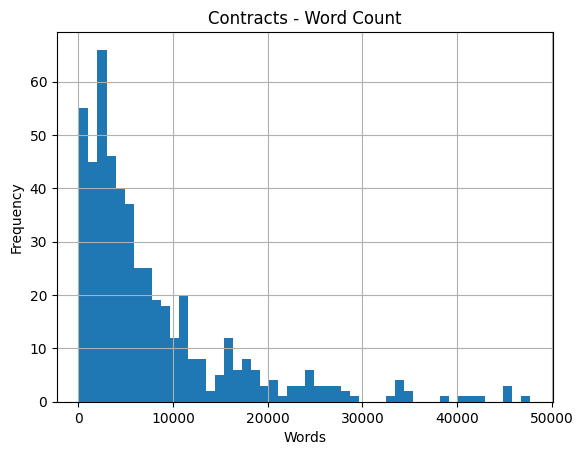

In [139]:
stats["num_words"].hist(bins=50)
plt.title("Contracts - Word Count")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [140]:
contracts.loc[stats["num_words"].sort_values().index[:10], ["filename", "text"]]

,filename,text
207,RMRGROUPINC_01_22_2020-EX-99.1-JOINT FILING AG...,Exhibit 99.1 JOINT FILING AGREEMENT The unders...
453,PcquoteComInc_19990721_S-1A_EX-10.11_6377149_E...,"[LOGO]\n\nAMENDMENT TO SECTION 2, PART B OF TH..."
485,"PRECIGEN,INC_01_22_2020-EX-99.1-JOINT FILING A...",Exhibit 99.1 JOINT FILING AGREEMENT Additional...
4,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEME...,Exhibit 1\n\nJOINT FILING AGREEMENT\n\nThe und...
66,"VIRGINGALACTICHOLDINGS,INC_04_08_2020-EX-99.1-...",Schedule 13 G CUSIP No. 30734W208 EXHIBIT 1 JO...
202,BLACKROCKMUNIHOLDINGSINVESTMENTQUALITYFUND_04_...,JOINT FILING AGREEMENT\n\nPursuant to and in a...
454,"MACY_S,INC_05_11_2020-EX-99.4-JOINT FILING AGR...",Exhibit 99.4 JOINT FILING AGREEMENT In accorda...
46,GALACTICOMMTECHNOLOGIESINC_11_07_1997-EX-10.46...,EXHIBIT 10.46\n\n ...
265,"SPRINGBANKPHARMACEUTICALS,INC_04_08_2020-EX-99...",EXHIBIT A JOINT FILING AGREEMENT In accordance...
133,CardlyticsInc_20180112_S-1_EX-10.16_11002987_E...,"SCHEDULE TO Software License, Customization an..."


In [141]:
contracts.loc[stats["num_words"].sort_values(ascending=False).index[:10], ["filename", "text"]]

,filename,text
470,"GOOSEHEADINSURANCE,INC_04_02_2018-EX-10.6-Fran...","Exhibit 10.6\n\nGoosehead Insurance Agency, LL..."
178,PhasebioPharmaceuticalsInc_20200330_10-K_EX-10...,Exhibit 10.21\n\nCertain information has been ...
188,"CERES,INC_01_25_2012-EX-10.20-Collaboration Ag...",Exhibit 10.20\n\nPages where confidential trea...
53,VerizonAbsLlc_20200123_8-K_EX-10.4_11952335_EX...,Exhibit 10.4\n\nFORM OF TRANSFER AND SERVICING...
255,"Array BioPharma Inc. - LICENSE, DEVELOPMENT AN...",[ * ] = Certain confidential information conta...
443,MANUFACTURERSSERVICESLTD_06_05_2000-EX-10.14-O...,Exhibit 10.14\n\n ...
259,RevolutionMedicinesInc_20200117_S-1_EX-10.1_11...,Exhibit 10.1\n\n[***] Certain information in t...
128,HarpoonTherapeuticsInc_20200312_10-K_EX-10.18_...,Exhibit 10.18 Confidential EXECUTION COPY\n\nC...
142,GRANTIERRAENERGYINC_05_07_2012-EX-10.6-TRANSPO...,EXHIBIT 10.6 TRANSPORTATION CONTRACT SPECI...
139,AtnInternationalInc_20191108_10-Q_EX-10.1_1187...,Exhibit 10.1 CERTAIN CONFIDENTIAL PORTIONS OF ...


In [142]:
contracts["num_words"] = s.str.split().str.len()
contracts["num_words"].describe()

count      510.000000
mean      7861.188235
std       8367.292546
min        109.000000
25%       2457.000000
50%       5006.000000
75%      10196.250000
max      47733.000000
Name: num_words, dtype: float64

In [143]:
structure = pd.DataFrame({
    "has_agreement_word": s.str.contains(r"\bagreement\b", case=False, regex=True, na=False),
    "has_shall": s.str.contains(r"\bshall\b", case=False, regex=True, na=False),
    "has_termination": s.str.contains(r"\btermination\b", case=False, regex=True, na=False),
    "has_governing_law": s.str.contains(r"\bgoverning law\b", case=False, regex=True, na=False),
    "has_party": s.str.contains(r"\bparty\b|\bparties\b", case=False, regex=True, na=False),
    "has_section": s.str.contains(r"\bsection\b|\barticle\b", case=False, regex=True, na=False),
    "has_currency": s.str.contains(r"[$€£]", regex=True, na=False),
    "has_dates": s.str.contains(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b|\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)", case=False, regex=True, na=False),
    "has_omitted": s.str.contains(r"<omitted>", case=False, regex=True, na=False),
    "has_redaction": s.str.contains(r"\*{3,}|_{3,}|\[\*\s*\*\s*\*\]", regex=True, na=False),
})
(structure.mean() * 100).sort_values(ascending=False)

has_dates             100.000000
has_agreement_word     99.411765
has_shall              97.843137
has_party              97.254902
has_section            87.058824
has_termination        86.470588
has_currency           63.137255
has_governing_law      54.705882
has_redaction          41.568627
has_omitted             0.000000
dtype: float64

In [144]:
noise = pd.DataFrame({
    "digit_ratio": s.apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1)),
    "uppercase_ratio": s.apply(lambda x: sum(c.isupper() for c in x) / max(len(x), 1)),
    "newline_ratio": s.apply(lambda x: x.count("\n") / max(len(x), 1)),
    "punct_ratio": s.apply(lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace()) / max(len(x), 1)),
})
noise.describe().T

,count,mean,std,min,25%,50%,75%,max
digit_ratio,510.0,0.012185,0.008757,0.002225,0.007483,0.010679,0.014299,0.094347
uppercase_ratio,510.0,0.068610,0.037219,0.022711,0.045652,0.058071,0.079204,0.344650
newline_ratio,510.0,0.007521,0.004773,0.000000,0.004119,0.006837,0.009326,0.038806
punct_ratio,510.0,0.037233,0.017250,0.017241,0.028672,0.032407,0.038223,0.183197


In [145]:
contracts.loc[noise["newline_ratio"].sort_values(ascending=False).index[:10], ["filename", "text"]]

,filename,text
104,BANGIINC_05_25_2005-EX-10-Premium Managed Host...,03/01/05\n\n607-1295 Richards Street 604.684...
276,XENCORINC_10_25_2013-EX-10.24-COLLABORATION AG...,Exhibit 10.24 ***Text Omitted and Filed Sepa...
118,CardlyticsInc_20180112_S-1_EX-10.16_11002987_E...,SCHEDULE B\n\nCustomization Schedule\n\nThis C...
231,"ONEMAINHOLDINGS,INC_02_20_2020-EX-99.D-JOINT F...",Exhibit D\n\nJOINT FILING AGREEMENT OneMain Ho...
185,CardlyticsInc_20180112_S-1_EX-10.16_11002987_E...,[***] = CONFIDENTIAL TREATMENT REQUESTED\n\nSC...
225,"MJBIOTECH,INC_12_06_2018-EX-99.01-JOINT VENTUR...",Exhibit 99.01 JOINT VENTURE AGREEMENT THIS JOI...
176,ELANDIAINTERNATIONALINC_04_25_2007-EX-10.21-Ou...,Exhibit 10.21\n\nConfidential treatment has be...
133,CardlyticsInc_20180112_S-1_EX-10.16_11002987_E...,"SCHEDULE TO Software License, Customization an..."
453,PcquoteComInc_19990721_S-1A_EX-10.11_6377149_E...,"[LOGO]\n\nAMENDMENT TO SECTION 2, PART B OF TH..."
99,FerroglobePlc_20150624_F-4A_EX-10.20_9154746_E...,Exhibit 10.20\n\n(TRANSLATION) OUTSOURCING AGR...


In [146]:
contracts.loc[noise["punct_ratio"].sort_values(ascending=False).index[:10], ["filename", "text"]]

,filename,text
453,PcquoteComInc_19990721_S-1A_EX-10.11_6377149_E...,"[LOGO]\n\nAMENDMENT TO SECTION 2, PART B OF TH..."
273,HPILHOLDING_01_07_2015-EX-99.1-COOPERATION AGR...,COOPERATION AGREEMENT made by and between ...
223,CHANGEPOINTCORP_03_08_2000-EX-10.6-LICENSE AND...,CONFIDENTIAL TREATMENT - REDACTED VERSION\n\n ...
106,GULFSOUTHMEDICALSUPPLYINC_12_24_1997-EX-4-AFFI...,EXHIBIT 4 AFFI...
36,LOYALTYPOINTINC_11_16_2004-EX-10.2-RESELLER AG...,EXHIBIT 10.2\n\n[LOGO AMERICAN EXPRESS] ...
338,HEALTHGATEDATACORP_11_24_1999-EX-10.1-HOSTING ...,[INITIALS ILLEGIBLE] ...
125,SLOVAKWIRELESSFINANCECOBV_03_28_2001-EX-4.(B)(...,Exhibit 4(b)(ii).3\n\n ...
468,PcquoteComInc_19990721_S-1A_EX-10.11_6377149_E...,[LOGO]\n\nSECOND AMENDMENT TO CO-BRANDING AGRE...
172,SUMMAFOURINC_06_19_1998-EX-10.3-SOFTWARE LICEN...,1 ...
276,XENCORINC_10_25_2013-EX-10.24-COLLABORATION AG...,Exhibit 10.24 ***Text Omitted and Filed Sepa...


In [147]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

vec = CountVectorizer(stop_words="english", max_features=10000)
X = vec.fit_transform(s)

freqs = np.asarray(X.sum(axis=0)).ravel()
words = np.array(vec.get_feature_names_out())

top_idx = freqs.argsort()[::-1][:30]

pd.DataFrame({
    "word": words[top_idx],
    "freq": freqs[top_idx]
})

,word,freq
0,shall,48794
1,agreement,43655
2,party,33277
3,parties,13523
4,section,13350
5,company,12637
6,information,10941
7,product,10920
8,date,10181
9,including,9924


In [148]:
master = pd.read_csv(MASTER_CSV)
master.shape

(510, 83)

In [149]:
master.head()

,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,['WEBSITE CONTENT LICENSE AGREEMENT'],WEBSITE CONTENT LICENSE AGREEMENT,"['PSiTech Corporation', 'Licensor', 'Licensee'...","PSiTech Corporation (""Licensor""); Empirical Ve...","['Feb 10, 2014']",2/10/14,"['Feb 10, 2014']",2/10/14,['The initial term of this Agreement commences...,...,[],No,[],No,[],No,[],No,[],No
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,['CONTENT LICENSE AGREEMENT'],CONTENT LICENSE AGREEMENT,"['YOU ON DEMAND HOLDINGS, INC.', 'Licensor', '...",Beijing Sun Seven Stars Culture Development Li...,"['December 21, 2015']",12/21/15,"['December 21, 2015']",12/21/15,"['The Term of this Agreement (the ""Term"") shal...",...,[],No,[],No,[],No,[],No,[],No


In [150]:
master.columns.tolist()[:20]

['Filename',
 'Document Name',
 'Document Name-Answer',
 'Parties',
 'Parties-Answer',
 'Agreement Date',
 'Agreement Date-Answer',
 'Effective Date',
 'Effective Date-Answer',
 'Expiration Date',
 'Expiration Date-Answer',
 'Renewal Term',
 'Renewal Term-Answer',
 'Notice Period To Terminate Renewal',
 'Notice Period To Terminate Renewal- Answer',
 'Governing Law',
 'Governing Law-Answer',
 'Most Favored Nation',
 'Most Favored Nation-Answer',
 'Competitive Restriction Exception']

In [151]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 83 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Filename                                    510 non-null    object
 1   Document Name                               510 non-null    object
 2   Document Name-Answer                        510 non-null    object
 3   Parties                                     510 non-null    object
 4   Parties-Answer                              509 non-null    object
 5   Agreement Date                              510 non-null    object
 6   Agreement Date-Answer                       465 non-null    object
 7   Effective Date                              510 non-null    object
 8   Effective Date-Answer                       359 non-null    object
 9   Expiration Date                             510 non-null    object
 10  Expiration Date-Answer    

In [152]:
master.iloc[:, 0].head(10)

0    CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...
1    EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...
2    FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...
3    GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...
4    IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...
5    DeltathreeInc_19991102_S-1A_EX-10.19_6227850_E...
6    EdietsComInc_20001030_10QSB_EX-10.4_2606646_EX...
7    IntegrityMediaInc_20010329_10-K405_EX-10.17_23...
8    MusclepharmCorp_20170208_10-KA_EX-10.38_989358...
9    TomOnlineInc_20060501_20-F_EX-4.46_749700_EX-4...
Name: Filename, dtype: object

In [153]:
master.iloc[:, 0].nunique(dropna=False), master.shape[0]

(510, 510)

In [154]:
txt_names = set(contracts["contract_name"].astype(str).str.strip())
master_names = set(master.iloc[:, 0].astype(str).str.replace(".pdf", "", regex=False).str.replace(".txt", "", regex=False).str.strip())

len(txt_names), len(master_names), len(txt_names.intersection(master_names))

(510, 510, 195)

In [155]:
sorted(list(txt_names - master_names))[:20]

['ABILITYINC_06_15_2020-EX-4.25-SERVICES AGREEMENT',
 'ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-EX-10.13-JOINT VENTURE AGREEMENT',
 'ACCURAYINC_09_01_2010-EX-10.31-DISTRIBUTOR AGREEMENT',
 'ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT AGREEMENT',
 'ADAPTIMMUNETHERAPEUTICSPLC_04_06_2017-EX-10.11-STRATEGIC ALLIANCE AGREEMENT',
 'ADIANUTRITION,INC_04_01_2005-EX-10.D2-RESELLER AGREEMENT',
 'ADMA BioManufacturing, LLC -  Amendment 3 to Manufacturing Agreement',
 'ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT',
 'ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT(1)',
 'AFSALABANCORPINC_08_01_1996-EX-1.1-AGENCY AGREEMENT',
 'AIRSPANNETWORKSINC_04_11_2000-EX-10.5-Distributor Agreement',
 'AIRTECHINTERNATIONALGROUPINC_05_08_2000-EX-10.4-FRANCHISE AGREEMENT',
 'ALAMOGORDOFINANCIALCORP_12_16_1999-EX-1-AGENCY AGREEMENT',
 'ALCOSTORESINC_12_14_2005-EX-10.26-AGENCY AGREEMENT',
 'ALLIANCEBANCORPINCOFPENNSYLVANIA_10_18_2006-EX-1.2-AGENCY AGREEMENT',
 'ALLISONTRANSMISSIONHOLDINGS

In [156]:
sorted(list(master_names - txt_names))[:20]

['ABILITYINC_06_15_2020-EX-4.25-SERVICES AGREEMENT.PDF',
 'ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-EX-10.13-JOINT VENTURE AGREEMENT.PDF',
 'ACCURAYINC_09_01_2010-EX-10.31-DISTRIBUTOR AGREEMENT.PDF',
 'ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT AGREEMENT.PDF',
 'ADAPTIMMUNETHERAPEUTICSPLC_04_06_2017-EX-10.11-STRATEGIC ALLIANCE AGREEMENT.PDF',
 'ADIANUTRITION,INC_04_01_2005-EX-10.D2-RESELLER AGREEMENT.PDF',
 'ADMA BioManufacturing, LLC -  Amendment #3 to Manufacturing Agreement .PDF',
 'ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT(1).PDF',
 'ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT.PDF',
 'AFSALABANCORPINC_08_01_1996-EX-1.1-AGENCY AGREEMENT.PDF',
 'AIRSPANNETWORKSINC_04_11_2000-EX-10.5-Distributor Agreement.PDF',
 'AIRTECHINTERNATIONALGROUPINC_05_08_2000-EX-10.4-FRANCHISE AGREEMENT.PDF',
 'ALAMOGORDOFINANCIALCORP_12_16_1999-EX-1-AGENCY AGREEMENT.PDF',
 'ALCOSTORESINC_12_14_2005-EX-10.26-AGENCY AGREEMENT.PDF',
 'ALLIANCEBANCORPINCOFPENNSYLVANIA_10_18_20

In [157]:
master_first_col = master.columns[0]
master[master_first_col].astype(str).value_counts().head(20)

Filename
CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf      1
ALLIANCEBANCORPINCOFPENNSYLVANIA_10_18_2006-EX-1.2-AGENCY AGREEMENT.PDF                 1
GIGGLESN_HUGS,INC_06_23_2016-EX-10.2-STRATEGIC ALLIANCE AGREEMENT.PDF                   1
FTENETWORKS,INC_02_18_2016-EX-99.4-STRATEGIC ALLIANCE AGREEMENT.PDF                     1
ENTRUSTINC_07_24_1998-EX-10.5-STRATEGIC ALLIANCE AGREEMENT.PDF                          1
DUOSTECHNOLOGIESGROUP,INC_04_21_2009-EX-10.1-STRATEGIC ALLIANCE AGREEMENT.PDF           1
COOLTECHNOLOGIES,INC_10_25_2017-EX-10.71-Strategic Alliance Agreement.PDF               1
ADAPTIMMUNETHERAPEUTICSPLC_04_06_2017-EX-10.11-STRATEGIC ALLIANCE AGREEMENT.PDF         1
CHERRYHILLMORTGAGEINVESTMENTCORP_09_26_2013-EX-10.1-Strategic Alliance Agreement.PDF    1
AURASYSTEMSINC_06_16_2010-EX-10.25-STRATEGIC ALLIANCE AGREEMENT.PDF                     1
BLUEROCKRESIDENTIALGROWTHREIT,INC_06_01_2016-EX-1.1-AGENCY AGREEMENT.PDF                1
B

In [158]:
(master[master_first_col].astype(str).value_counts() > 1).sum()

np.int64(0)

In [159]:
master.isna().sum().sort_values(ascending=False).head(20)

Notice Period To Terminate Renewal- Answer    409
Renewal Term-Answer                           347
Expiration Date-Answer                        181
Effective Date-Answer                         151
Governing Law-Answer                           76
Agreement Date-Answer                          45
Parties-Answer                                  1
Filename                                        0
Irrevocable Or Perpetual License-Answer         0
Irrevocable Or Perpetual License                0
Unlimited/All-You-Can-Eat-License-Answer        0
Unlimited/All-You-Can-Eat-License               0
Affiliate License-Licensee-Answer               0
Affiliate License-Licensee                      0
Affiliate License-Licensor-Answer               0
Affiliate License-Licensor                      0
Non-Transferable License                        0
Non-Transferable License-Answer                 0
Source Code Escrow-Answer                       0
License Grant-Answer                            0


In [160]:
(master.isna().mean() * 100).sort_values(ascending=False).head(20)

Notice Period To Terminate Renewal- Answer    80.196078
Renewal Term-Answer                           68.039216
Expiration Date-Answer                        35.490196
Effective Date-Answer                         29.607843
Governing Law-Answer                          14.901961
Agreement Date-Answer                          8.823529
Parties-Answer                                 0.196078
Filename                                       0.000000
Irrevocable Or Perpetual License-Answer        0.000000
Irrevocable Or Perpetual License               0.000000
Unlimited/All-You-Can-Eat-License-Answer       0.000000
Unlimited/All-You-Can-Eat-License              0.000000
Affiliate License-Licensee-Answer              0.000000
Affiliate License-Licensee                     0.000000
Affiliate License-Licensor-Answer              0.000000
Affiliate License-Licensor                     0.000000
Non-Transferable License                       0.000000
Non-Transferable License-Answer                0

In [161]:
contracts["contract_name"].sample(20, random_state=42)

480    VnueInc_20150914_8-K_EX-10.1_9259571_EX-10.1_P...
449    2ThemartComInc_19990826_10-12G_EX-10.10_670028...
475    ZONDWINDSYSTEMPARTNERSLTDSERIES85-B_04_03_2006...
434    ICORECONNECTINC_10_13_2010-EX-7.1-Strategic Al...
368    ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING...
55           WPPPLC_04_30_2020-EX-4.28-SERVICE AGREEMENT
322    IVILLAGEINC_03_17_1999-EX-10.16-SPONSORSHIP AG...
76     ELECTRAMECCANICA VEHICLES CORP. - Manufacturin...
504    BLUEROCKRESIDENTIALGROWTHREIT,INC_06_01_2016-E...
347    GentechHoldingsInc_20190808_1-A_EX1A-6 MAT CTR...
415    ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-...
220    ArcaUsTreasuryFund_20200207_N-2_EX-99.K5_11971...
117    RUBIOSRESTAURANTSINC_03_31_2008-EX-10.75-SPONS...
249    GpaqAcquisitionHoldingsInc_20200123_S-4A_EX-10...
173    MACROGENICSINC_08_02_2013-EX-10-COLLABORATION ...
93                        NUVEEN - REMARKETING AGREEMENT
325     BIOPURECORP_06_30_1999-EX-10.13-AGENCY AGREEMENT
275    SPORTHALEYINC_09_29_1997

In [162]:
possible_types = [
    "license", "service", "supply", "development", "marketing", "distribution",
    "consulting", "manufacturing", "franchise", "hosting", "maintenance",
    "joint venture", "collaboration", "promotion", "outsourcing", "sponsorship",
    "strategic alliance", "transportation", "agency", "endorsement", "ip"
]

def guess_type(name):
    name = str(name).lower()
    for t in possible_types:
        if t in name:
            return t
    return "other"

contracts["guessed_type"] = contracts["contract_name"].apply(guess_type)
contracts["guessed_type"].value_counts()

guessed_type
other                 117
license                41
service                38
development            32
strategic alliance     31
maintenance            31
sponsorship            30
supply                 24
endorsement            23
hosting                16
outsourcing            16
marketing              16
franchise              15
agency                 14
promotion              11
collaboration          11
consulting             11
joint venture          10
manufacturing          10
transportation         10
distribution            2
ip                      1
Name: count, dtype: int64

In [163]:
summary = pd.Series({
    "n_rows": len(contracts),
    "n_unique_texts": s.nunique(),
    "duplicate_pct": round(s.duplicated().mean() * 100, 2),
    "avg_words": round(stats["num_words"].mean(), 2),
    "median_words": round(stats["num_words"].median(), 2),
    "avg_lines": round(stats["num_lines"].mean(), 2),
    "has_agreement_word_pct": round(structure["has_agreement_word"].mean() * 100, 2),
    "has_shall_pct": round(structure["has_shall"].mean() * 100, 2),
    "has_party_pct": round(structure["has_party"].mean() * 100, 2),
    "has_section_pct": round(structure["has_section"].mean() * 100, 2),
    "has_redaction_pct": round(structure["has_redaction"].mean() * 100, 2),
    "has_omitted_pct": round(structure["has_omitted"].mean() * 100, 2),
})
summary

n_rows                     510.00
n_unique_texts             509.00
duplicate_pct                0.20
avg_words                 7861.19
median_words              5006.00
avg_lines                  383.32
has_agreement_word_pct      99.41
has_shall_pct               97.84
has_party_pct               97.25
has_section_pct             87.06
has_redaction_pct           41.57
has_omitted_pct              0.00
dtype: float64

INSIGHTS:
- dataset is clean and usable (510 contracts loaded, no missing text, no empty contracts, almost no duplicates)
- one txt file means one contract
- master_clauses.csv also has 510 rows
- no row duplication inside of master_clauses.csv
- contracts ar emuch longer than the other document classes (MUST TAKE INTO ACOCUNT FOR PREPROCESSING, might need to truncate or compare them)
- good legal document signals
- has_dates = 100%, has_currency = 63.1% means that dates are not useful to distinguish contracts from invoices and neiher is currecy, prob need combinations of features
- has_redaction = 41.6%, this means contract texts contain OCR / PDF-conversion noise (need to normalize artifacts, collapse repeated whitespace and maybe remove things like [LOGO],CONFIDENTIAL TREATMENT, Exhibit 10.x, etx) have to be careful to no overclean too early, cuz some tokens may be helpful to identify contracts. SHOULD DO light cleaning and stronger cleaning
- has_omitted = 0%, for classification on full text, this feature is irrelevant

noise features:
- uppercase ratio is nonzero and relatively high
- newline ratio is moderate
- punctuation ratio is moderate
What does this mean:unlike emails, the contract text is not fully normalized/lowercased, formatting still carries signal, section headings / titles / enumerations may help classification

Duplications:
- Only one duplicate pair exists: ADUROBIOTECH ... CONSULTING AGREEMENT and (1) variant so dropping exact duplicate text is enough


master_clauses.csv:
- for extraction/clause labeling, not for document classification
- 83 columns
- one row per contract
- many -Answer columns
- lots of missingness in answer columns for categories that are absent

Contract subtype diversity: many different types so very diverse which mean that is less likely to overfit


# Invoices (`converted_invoice_dataset.csv`)

English Western-style invoices sourced from a structured invoice dataset. Each row contains a raw invoice text (`Input`) and a structured JSON representation of its fields (`Final_Output`). Only `Input` is used for classification.

In [164]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

INVOICE_CSV = Path("../data/raw/invoices/converted_invoice_dataset.csv")
invoices = pd.read_csv(INVOICE_CSV)
print("Shape:", invoices.shape)
invoices.head(3)


Shape: (67, 2)


,Input,Final_Output
0,Cream and White Simple Minimalist Catering Ser...,"{""TOTAL_AMOUNT"": ""$1000"", ""DUE_AMOUNT"": ""$550""..."
1,Beige Elegant Professional Business Invoice\n\...,"{""INVOICE_NUMBER"": ""#01234"", ""BILLED_TO"": ""Est..."
2,Black and White Clean Modern Invoice\n\nConsul...,"{""BILL_TO"": ""SALFORD & CO."", ""BANK_NAME"": ""Bor..."


In [165]:
invoices.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Input         67 non-null     object
 1   Final_Output  67 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [166]:
s = invoices["Input"].fillna("").astype(str).str.strip()

{
    "total": len(s),
    "empty": int((s == "").sum()),
    "duplicates": int(s.duplicated().sum()),
    "duplicate_pct": round(s.duplicated().mean() * 100, 2),
}


{'total': 67, 'empty': 0, 'duplicates': 3, 'duplicate_pct': np.float64(4.48)}

count     67.0
mean      84.1
std       21.4
min       51.0
25%       70.0
50%       82.0
75%       91.5
max      173.0
Name: Input, dtype: float64


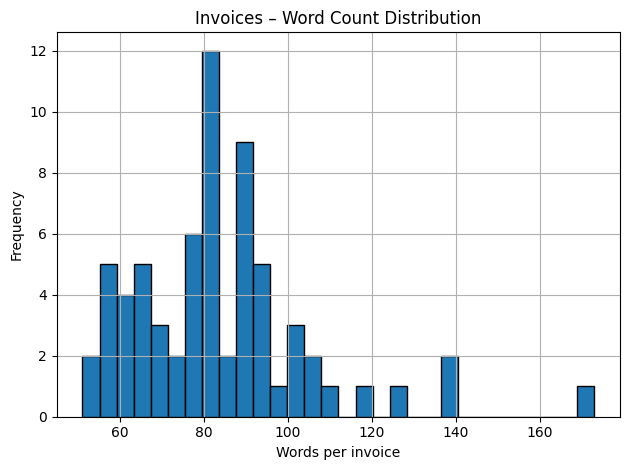

In [167]:
wc = s.str.split().str.len()
invoices["num_words"] = wc
print(wc.describe().round(1))

wc.hist(bins=30, edgecolor="black")
plt.title("Invoices – Word Count Distribution")
plt.xlabel("Words per invoice")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [168]:
print("--- 5 shortest invoices ---")
print(invoices.loc[wc.sort_values().index[:5], ["num_words", "Input"]].to_string())
print()
print("--- 5 longest invoices ---")
print(invoices.loc[wc.sort_values(ascending=False).index[:5], ["num_words", "Input"]].to_string())


--- 5 shortest invoices ---
    num_words                                                                                                                                                                                                                                                                                                                                                                                                                        Input
43         51                                                                                         Black Elegant Restaurant Invoice\n\nTo:\nISABEL MERCADO\nBORCELLE\nDate:\nAUGUST 9 2029\n30.000\n20.000\nFood D Number D,\nModel D\nNumber E, Model E\nNumber F, Model F\nProduct(s) Details Price Total Qty\nFood E\nDrinks F 10.000\n2\n3\n1\n60.000\n60.000\n10.000\nSubtotal\nTax\nTotal Rp133.000\nRp130.000\nRp13.000\nInvoice
40         55                                                                      Modern Business Invoice\n\nBUSINESS

has 'invoice'          100.0
has total/amount        95.5
has 'bill to'           11.9
has 'due date'          14.9
has 'payment'           74.6
has subtotal            37.3
has tax/vat             59.7
has currency symbol     95.5
has numeric amount      76.1


/var/folders/db/5m_pdzk97r5blqcr_x1g9znh0000gn/T/ipykernel_27183/1353294380.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  k: round(s.str.contains(v, case=False, regex=True).mean() * 100, 1)


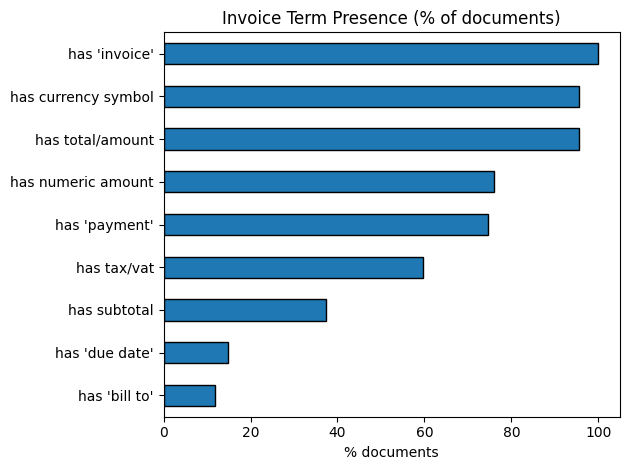

In [169]:
patterns = {
    "has 'invoice'": r"\binvoice\b",
    "has total/amount": r"\b(total|amount)\b",
    "has 'bill to'": r"\bbill\s*to\b",
    "has 'due date'": r"\bdue\s*date\b",
    "has 'payment'": r"\bpayment\b",
    "has subtotal": r"\bsubtotal\b",
    "has tax/vat": r"\b(tax|vat|gst)\b",
    "has currency symbol": r"[\$\€\£]",
    "has numeric amount": r"\d+[\.,]\d{2}",
}

presence = {
    k: round(s.str.contains(v, case=False, regex=True).mean() * 100, 1)
    for k, v in patterns.items()
}
pres_df = pd.Series(presence).rename("% docs containing pattern")
print(pres_df.to_string())

pres_df.sort_values().plot(kind="barh", edgecolor="black")
plt.title("Invoice Term Presence (% of documents)")
plt.xlabel("% documents")
plt.tight_layout()
plt.show()


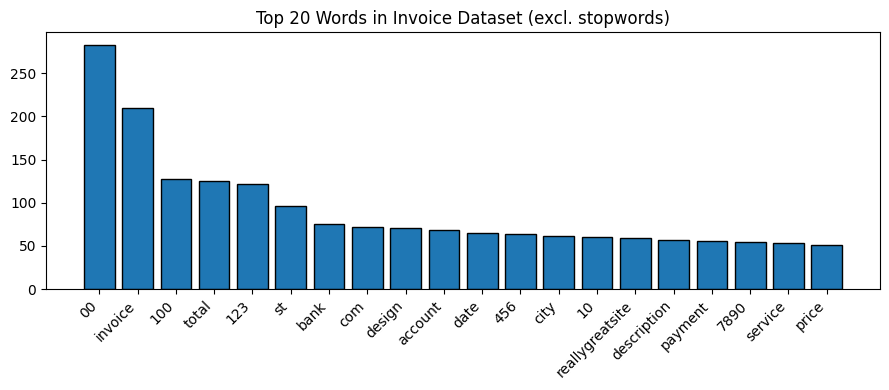

In [170]:
vec = CountVectorizer(stop_words="english", max_features=3000)
X_vec = vec.fit_transform(s)
freqs = np.asarray(X_vec.sum(axis=0)).flatten()
top_words = sorted(zip(vec.get_feature_names_out(), freqs), key=lambda x: -x[1])[:20]

words, counts = zip(*top_words)
plt.figure(figsize=(9, 4))
plt.bar(words, counts, edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Words in Invoice Dataset (excl. stopwords)")
plt.tight_layout()
plt.show()


In [171]:
noise = pd.DataFrame({
    "digit_ratio":     s.apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1)),
    "uppercase_ratio": s.apply(lambda x: sum(c.isupper() for c in x) / max(len(x), 1)),
    "newline_ratio":   s.apply(lambda x: x.count("\\n") / max(len(x), 1)),
})
print(noise.describe().round(4))


       digit_ratio  uppercase_ratio  newline_ratio
count      67.0000          67.0000           67.0
mean        0.1537           0.1887            0.0
std         0.0286           0.0690            0.0
min         0.0793           0.0793            0.0
25%         0.1425           0.1481            0.0
50%         0.1470           0.1766            0.0
75%         0.1724           0.2155            0.0
max         0.2219           0.5452            0.0


In [172]:
summary = pd.Series({
    "n_rows":           len(invoices),
    "n_unique_texts":   int(s.nunique()),
    "duplicate_pct":    round(s.duplicated().mean() * 100, 2),
    "empty_texts":      int((s == "").sum()),
    "mean_words":       round(wc.mean(), 1),
    "median_words":     round(wc.median(), 1),
    "min_words":        int(wc.min()),
    "max_words":        int(wc.max()),
    "pct_has_invoice":  round(s.str.contains(r'\binvoice\b', case=False).mean() * 100, 1),
    "pct_has_total":    round(s.str.contains(r'\btotal\b', case=False).mean() * 100, 1),
})
summary


n_rows              67.00
n_unique_texts      64.00
duplicate_pct        4.48
empty_texts          0.00
mean_words          84.10
median_words        82.00
min_words           51.00
max_words          173.00
pct_has_invoice    100.00
pct_has_total       95.50
dtype: float64

**INSIGHTS**
- **67 invoices** total, all English Western-style (not Asian receipts)
- **3 duplicates** (4.5%) — minor, will be dropped in preprocessing
- **Short documents**: mean 84 words, max 173 — much shorter than emails or contracts
- **100% contain the word 'invoice'** → strong class signal
- **95%+ contain 'total' or 'amount'** → reliable structured vocabulary
- **Low 'bill to' / 'due date' presence** (12–15%) → templates vary considerably
- **High digit ratio** vs other classes → numbers, prices, quantities are distinguishing
- **Limitation**: only 67 samples — the preprocessing notebook adds 500 synthetic English invoices in 5 layout styles to compensate for the small class size

contracts = strongest legal structure
emails = noisiest, many duplicates
news = clean but topic-based
invoices = compact, highly structured, extraction-friendly